# 01 — Data Exploration

Fetch OHLCV data for all tracked assets from Binance, compute technical indicators, and save to parquet.

In [24]:
# ── Asset configuration ───────────────────────────────────────────────────────
# Edit this dict to add/remove symbols. All downstream cells derive from it.
COIN_IDS = {
    "BTCUSDT":  "bitcoin",
    "ETHUSDT":  "ethereum",
    "BNBUSDT":  "binancecoin",
    "XRPUSDT":  "ripple",
    "SOLUSDT":  "solana",
    "ADAUSDT":  "cardano",
    "DOGEUSDT": "dogecoin",
    "AVAXUSDT": "avalanche-2",
    "DOTUSDT":  "polkadot",
    "LINKUSDT": "chainlink",
}

INTERVAL = '1h'


In [25]:
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import requests

from hmats.data.binance_store import fetch_and_store, load
from hmats.data.pipeline import compute_indicators

warnings.filterwarnings('ignore', category=FutureWarning)
pd.options.display.max_columns = 30

# ── Research-grade plot style ─────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.framealpha": 0.85,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

ACCENT   = '#F7931A'  # Bitcoin orange
BLUE     = '#2962FF'
GREY     = '#9E9E9E'
DARKGREY = '#424242'

REPO_ROOT = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()

RAW_DIR = REPO_ROOT / 'data' / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = REPO_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## 1. Market cap & earliest candle availability

Fetches CoinGecko ATH data and Binance earliest candle dates for each symbol.
If `crypto_market_caps.csv` already exists the API calls are skipped entirely.

In [26]:
MARKET_CAPS_PATH = RAW_DIR / 'crypto_market_caps.csv'

def _earliest_candle(symbol: str) -> str | None:
    r = requests.get(
        'https://api.binance.com/api/v3/klines',
        params={'symbol': symbol, 'interval': '1h', 'startTime': 0, 'limit': 1},
        timeout=10,
    )
    if r.status_code != 200:
        return None
    data = r.json()
    if not data:
        return None
    dt = datetime.fromtimestamp(data[0][0] / 1000, tz=timezone.utc)
    return dt.strftime('%Y-%m-%d')


def _fetch_coingecko() -> dict[str, dict]:
    r = requests.get(
        'https://api.coingecko.com/api/v3/coins/markets',
        params={
            'vs_currency': 'usd',
            'ids': ','.join(COIN_IDS.values()),
            'order': 'market_cap_desc',
            'per_page': 20,
            'sparkline': 'false',
        },
        timeout=15,
    )
    r.raise_for_status()
    return {c['id']: c for c in r.json()}


if MARKET_CAPS_PATH.exists():
    print(f'crypto_market_caps.csv already exists — loading from {MARKET_CAPS_PATH}')
    caps_df = pd.read_csv(MARKET_CAPS_PATH)
else:
    print('Fetching CoinGecko + Binance availability data...')
    cg = _fetch_coingecko()
    rows = []
    for symbol, coin_id in COIN_IDS.items():
        earliest = _earliest_candle(symbol)
        data = cg.get(coin_id)
        ath = data['ath'] if data else None
        supply = data['circulating_supply'] if data else None
        ath_date = data['ath_date'][:10] if data else None
        peak = ath * supply if ath and supply else None
        rows.append({
            'symbol':              symbol,
            'earliest_1h_candle': earliest,
            'ath_price_usd':      ath,
            'ath_date':           ath_date,
            'circulating_supply': supply,
            'peak_market_cap_usd': peak,
        })
        print(f'  {symbol:<12} earliest={earliest}  peak_cap=${peak/1e9:.1f}B' if peak else f'  {symbol:<12} earliest={earliest}  peak_cap=N/A')
    caps_df = pd.DataFrame(rows)
    caps_df.to_csv(MARKET_CAPS_PATH, index=False)
    print(f'\nSaved → {MARKET_CAPS_PATH}')

caps_df


crypto_market_caps.csv already exists — loading from /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/raw/crypto_market_caps.csv


,symbol,earliest_1h_candle,ath_price_usd,ath_date,circulating_supply,peak_market_cap_usd
0,BTCUSDT,2017-08-17,126080.000000,2025-10-06,2.002352e+07,2.524566e+12
1,ETHUSDT,2017-08-17,4946.050000,2025-08-24,1.206874e+08,5.969258e+11
2,BNBUSDT,2017-11-06,1369.990000,2025-10-13,1.347859e+08,1.846554e+11
3,XRPUSDT,2018-05-04,3.650000,2025-07-18,6.179623e+10,2.255562e+11
4,SOLUSDT,2020-08-11,293.310000,2025-01-19,5.763263e+08,1.690423e+11
5,ADAUSDT,2018-04-17,3.090000,2021-09-02,3.697472e+10,1.142519e+11
6,DOGEUSDT,2019-07-05,0.731578,2021-05-08,1.541004e+11,1.127365e+11
7,AVAXUSDT,2020-09-22,144.960000,2021-11-21,4.317720e+08,6.258966e+10
8,DOTUSDT,2020-08-18,54.980000,2021-11-04,1.682241e+09,9.248959e+10
9,LINKUSDT,2019-01-16,52.700000,2021-05-10,7.271000e+08,3.831817e+10


### Figure 1 — Dataset overview table

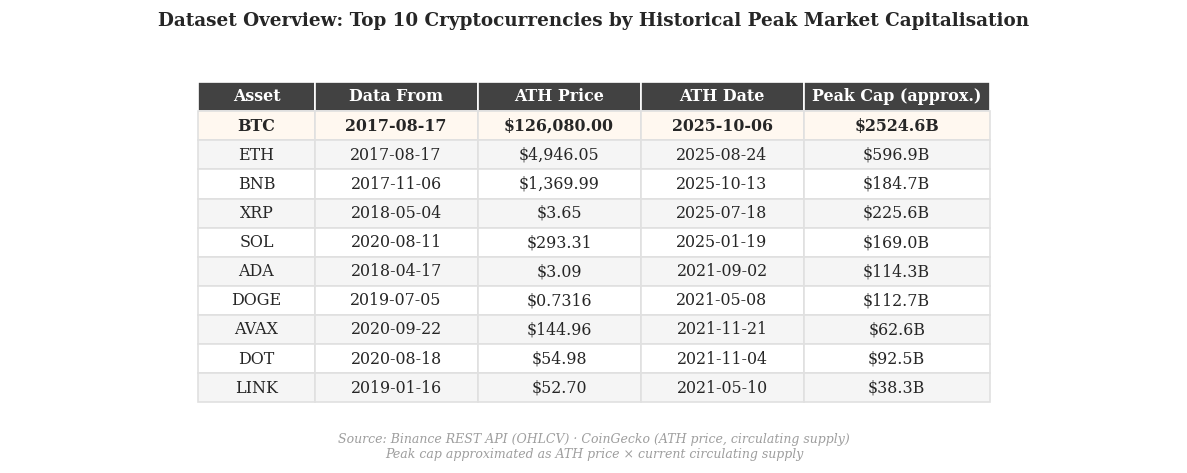

In [27]:
_df = caps_df.copy()
_df['Asset']     = _df['symbol'].str.replace('USDT', '')
_df['ATH Price'] = _df['ath_price_usd'].apply(lambda x: f'${x:,.2f}' if x >= 1 else f'${x:.4f}')
_df['ATH Date']  = _df['ath_date']
_df['Peak Cap']  = _df['peak_market_cap_usd'].apply(lambda x: f'${x/1e9:.1f}B')
_df['Data From'] = _df['earliest_1h_candle']

_td = _df[['Asset', 'Data From', 'ATH Price', 'ATH Date', 'Peak Cap']].values
_cl = ['Asset', 'Data From', 'ATH Price', 'ATH Date', 'Peak Cap (approx.)']

fig1, ax1 = plt.subplots(figsize=(10, 4.2))
ax1.axis('off')
tbl = ax1.table(cellText=_td, colLabels=_cl, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.6)

for j in range(len(_cl)):
    cell = tbl[0, j]
    cell.set_facecolor(DARKGREY)
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('white')

for i in range(1, len(_td) + 1):
    bg = '#FFF8F0' if i == 1 else ('#F5F5F5' if i % 2 == 0 else 'white')
    for j in range(len(_cl)):
        cell = tbl[i, j]
        cell.set_facecolor(bg)
        cell.set_edgecolor('#E0E0E0')
        if i == 1:
            cell.set_text_props(fontweight='bold')

for j, w in enumerate([0.10, 0.14, 0.14, 0.14, 0.16]):
    for i in range(len(_td) + 1):
        tbl[i, j].set_width(w)

fig1.suptitle(
    'Dataset Overview: Top 10 Cryptocurrencies by Historical Peak Market Capitalisation',
    fontsize=11, fontweight='bold', y=0.97,
)
ax1.text(
    0.5, -0.04,
    'Source: Binance REST API (OHLCV) · CoinGecko (ATH price, circulating supply)\n'
    'Peak cap approximated as ATH price × current circulating supply',
    ha='center', va='top', transform=ax1.transAxes,
    fontsize=7.5, color=GREY, style='italic',
)
fig1.tight_layout(rect=[0, 0.04, 1, 0.97])
fig1.savefig(FIGURES_DIR / 'fig1_market_cap_table.png')
plt.show()


## 2. Fetch OHLCV for all symbols

For each symbol, `fetch_and_store` fetches from its earliest available candle.
Re-running this cell is safe — only new rows since the last stored timestamp are downloaded (incremental update).

In [28]:
for symbol in COIN_IDS:
    row = caps_df[caps_df['symbol'] == symbol]
    if row.empty:
        print(f'  {symbol}: not found in caps_df — skipping')
        continue
    start_date = row.iloc[0]['earliest_1h_candle']
    print(f'Fetching {symbol} from {start_date}...')
    df = fetch_and_store(
        symbol=symbol,
        interval=INTERVAL,
        start=start_date,
        store_dir=str(RAW_DIR),
    )
    print(f'  {len(df):>7,} rows  {df.index.min().date()} → {df.index.max().date()}')


Fetching BTCUSDT from 2017-08-17...
   76,237 rows  2017-08-17 → 2026-05-04
Fetching ETHUSDT from 2017-08-17...
   76,237 rows  2017-08-17 → 2026-05-04
Fetching BNBUSDT from 2017-11-06...
   74,300 rows  2017-11-06 → 2026-05-04
Fetching XRPUSDT from 2018-05-04...
   70,033 rows  2018-05-04 → 2026-05-04
Fetching SOLUSDT from 2020-08-11...
   50,183 rows  2020-08-11 → 2026-05-04
Fetching ADAUSDT from 2018-04-17...
   70,445 rows  2018-04-17 → 2026-05-04
Fetching DOGEUSDT from 2019-07-05...
   59,825 rows  2019-07-05 → 2026-05-04
Fetching AVAXUSDT from 2020-09-22...
   49,175 rows  2020-09-22 → 2026-05-04
Fetching DOTUSDT from 2020-08-18...
   49,998 rows  2020-08-18 → 2026-05-04
Fetching LINKUSDT from 2019-01-16...
   63,891 rows  2019-01-16 → 2026-05-04


## 3. Sanity check — stored files

In [29]:
print(f'Files in {RAW_DIR}:\n')
for p in sorted(RAW_DIR.glob('*.parquet')):
    df_check = pd.read_parquet(p)
    print(f'  {p.name:<30} {len(df_check):>7,} rows  '
          f'{df_check.index.min().date()} → {df_check.index.max().date()}')


Files in /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/raw:

  ADAUSDT_1h.parquet              70,445 rows  2018-04-17 → 2026-05-04
  AVAXUSDT_1h.parquet             49,175 rows  2020-09-22 → 2026-05-04
  BNBUSDT_1h.parquet              74,300 rows  2017-11-06 → 2026-05-04
  BTCUSDT_1h.parquet              76,237 rows  2017-08-17 → 2026-05-04
  DOGEUSDT_1h.parquet             59,825 rows  2019-07-05 → 2026-05-04
  DOTUSDT_1h.parquet              49,998 rows  2020-08-18 → 2026-05-04
  ETHUSDT_1h.parquet              76,237 rows  2017-08-17 → 2026-05-04
  LINKUSDT_1h.parquet             63,891 rows  2019-01-16 → 2026-05-04
  SOLUSDT_1h.parquet              50,183 rows  2020-08-11 → 2026-05-04
  XRPUSDT_1h.parquet              70,033 rows  2018-05-04 → 2026-05-04
  btc_daily.parquet                2,316 rows  2020-01-01 → 2026-05-04


## 4. BTC daily chart

Load daily candles, compute indicators on the daily timeframe, and plot a research-grade chart with log-scale price, SMAs, Bollinger Bands and colour-coded volume bars.

In [30]:
# Resample hourly data to daily — no separate 1d fetch needed
btc_1h = load('BTCUSDT', '1h', store_dir=str(RAW_DIR))
btc_1h.index = btc_1h.index.tz_localize(None) if btc_1h.index.tz else btc_1h.index

btc_daily = btc_1h.resample('1D').agg({
    'open':   'first',
    'high':   'max',
    'low':    'min',
    'close':  'last',
    'volume': 'sum',
}).dropna()

# Indicators on daily candles
close = btc_daily['close']
btc_daily['SMA_50']   = close.rolling(50).mean()
btc_daily['SMA_200']  = close.rolling(200).mean()
_bb_mid               = close.rolling(20).mean()
_bb_std               = close.rolling(20).std()
btc_daily['BB_upper'] = _bb_mid + 2 * _bb_std
btc_daily['BB_lower'] = _bb_mid - 2 * _bb_std
btc_daily['vol_ma30'] = btc_daily['volume'].rolling(30).mean()

print(f'{len(btc_daily):,} daily rows  {btc_daily.index.min().date()} → {btc_daily.index.max().date()}')


3,183 daily rows  2017-08-17 → 2026-05-04


### Figure 2 — BTC/USDT daily price (log scale) with volume

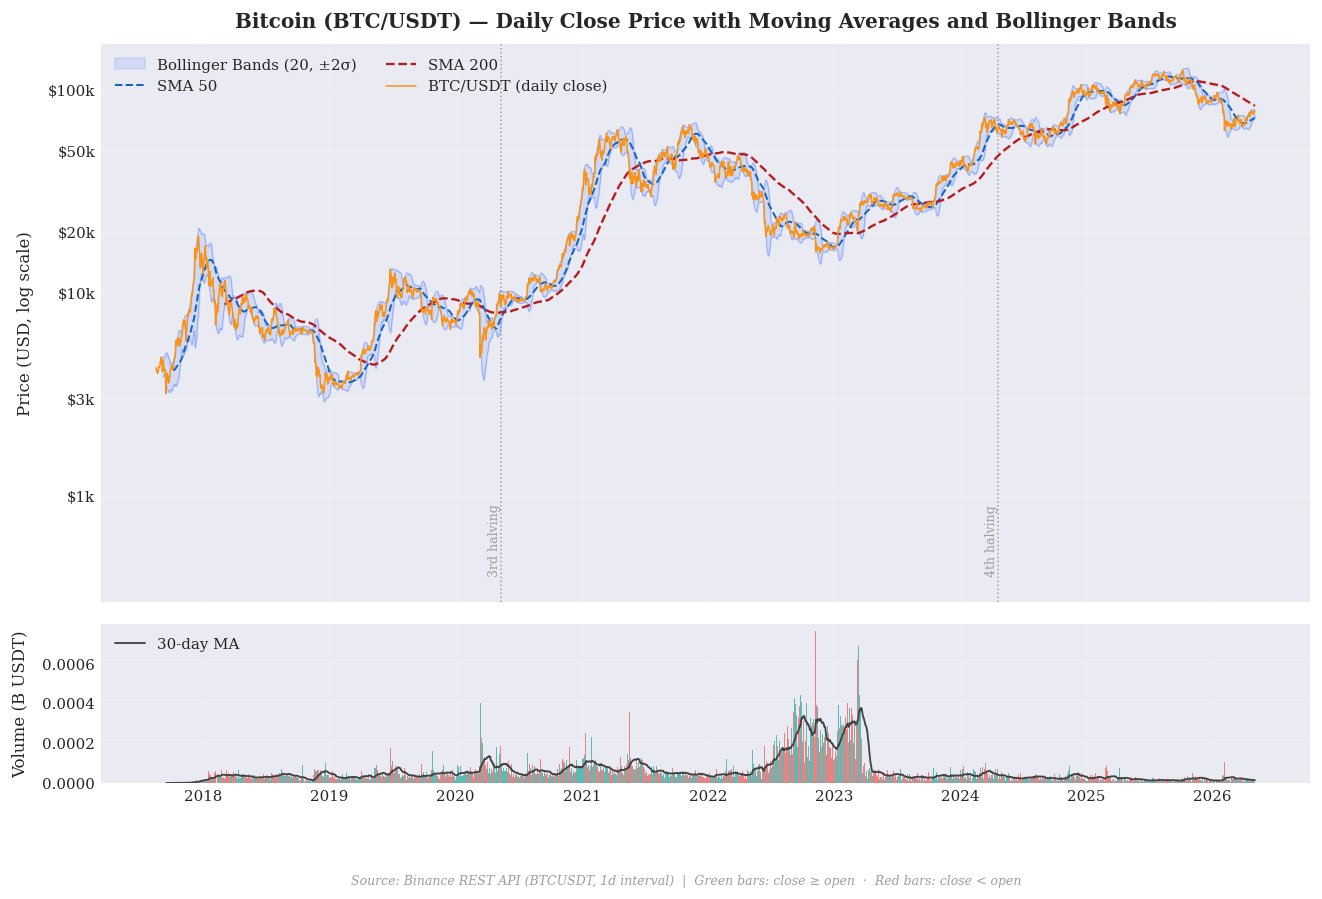

In [35]:
fig2, (ax_p, ax_v) = plt.subplots(
    2, 1, figsize=(13, 8),
    gridspec_kw={'height_ratios': [3.5, 1], 'hspace': 0.06},
    sharex=True,
)

# ── Price panel ───────────────────────────────────────────────────────────────
ax_p.fill_between(
    btc_daily.index, btc_daily['BB_lower'], btc_daily['BB_upper'],
    alpha=0.12, color=BLUE, label='Bollinger Bands (20, ±2σ)', zorder=1,
)
ax_p.plot(btc_daily.index, btc_daily['BB_upper'], lw=0.5, color=BLUE, alpha=0.35, zorder=2)
ax_p.plot(btc_daily.index, btc_daily['BB_lower'], lw=0.5, color=BLUE, alpha=0.35, zorder=2)
ax_p.plot(btc_daily.index, btc_daily['SMA_50'],   lw=1.2, color='#1565C0', ls='--', label='SMA 50',  zorder=3)
ax_p.plot(btc_daily.index, btc_daily['SMA_200'],  lw=1.4, color='#B71C1C', ls='--', label='SMA 200', zorder=3)
ax_p.plot(btc_daily.index, btc_daily['close'],    lw=0.9, color=ACCENT, label='BTC/USDT (daily close)', zorder=4)

ax_p.set_yscale('log')
ax_p.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}k' if x >= 1000 else f'${x:.0f}'
))
ax_p.yaxis.set_minor_formatter(mticker.NullFormatter())
ax_p.set_yticks([1000, 3000, 10000, 20000, 50000, 100000, 200000])
ax_p.set_ylim(300, btc_daily['close'].max() * 1.35)
ax_p.set_ylabel('Price (USD, log scale)', labelpad=8)
ax_p.legend(loc='upper left', ncol=2)
ax_p.set_title(
    'Bitcoin (BTC/USDT) — Daily Close Price with Moving Averages and Bollinger Bands',
    fontsize=12, fontweight='bold', pad=10,
)
ax_p.grid(axis='y', which='major', alpha=0.3)
ax_p.grid(axis='x', alpha=0.15)

# Halving annotations
for _date, _label in [('2020-05-11', '3rd halving'), ('2024-04-19', '4th halving')]:
    _x = pd.Timestamp(_date)
    if btc_daily.index.min() <= _x <= btc_daily.index.max():
        ax_p.axvline(_x, color=GREY, lw=0.9, ls=':', zorder=1)
        ax_p.text(_x, 400, _label, rotation=90, fontsize=7.5,
                  color=GREY, va='bottom', ha='right')

# ── Volume panel ─────────────────────────────────────────────────────────────
_colors = np.where(btc_daily['close'] >= btc_daily['open'], '#26A69A', '#EF5350')
ax_v.bar(btc_daily.index, btc_daily['volume'] / 1e9, width=1, color=_colors, alpha=0.7, zorder=2)
ax_v.plot(btc_daily.index, btc_daily['vol_ma30'] / 1e9, color=DARKGREY, lw=1.1,
          label='30-day MA', zorder=3)
ax_v.set_ylabel('Volume (B USDT)', labelpad=8)
ax_v.legend(loc='upper left')
ax_v.grid(axis='y', alpha=0.25)
ax_v.grid(axis='x', alpha=0.15)

ax_v.xaxis.set_major_locator(mdates.YearLocator())
ax_v.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_v.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))

fig2.text(
    0.5, 0.005,
    'Source: Binance REST API (BTCUSDT, 1d interval)  |  '
    'Green bars: close ≥ open  ·  Red bars: close < open',
    ha='center', fontsize=7.5, color=GREY, style='italic',
)
fig2.savefig(FIGURES_DIR / 'fig2_btc_price_volume.png')
plt.show()
